In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("[*] Loading combined Tuesday and Wednesday datasets...")
df_tuesday = pd.read_csv("../data/processed/Tuesday/Tuesday_final_labeled_features.csv")
df_wednesday = pd.read_csv("../data/processed/Wednesday/Wednesday_final_labeled_features.csv")
df = pd.concat([df_tuesday, df_wednesday], ignore_index=True)

print(f"[+] Loaded {df.shape[0]} rows and {df.shape[1]} columns.")

[*] Loading combined Tuesday and Wednesday datasets...
[+] Loaded 614254 rows and 116 columns.


In [2]:
print("[*] Engineering Tier 2 Granular Multi-Class Labels...")

def map_threat_class(label):
    if label == 'BENIGN':
        return 0
    elif label in ['DoS-Slowloris', 'DoS-SlowHTTPTest']:
        return 1 # Low & Slow Connection Exhaustion
    elif label in ['DoS-Hulk', 'DoS-GoldenEye']:
        return 2 # Layer 7 Web Floods
    elif label in ['FTP-Patator', 'SSH-Patator']:
        return 3 # Brute Force
    elif label == 'Heartbleed':
        return 4 # Exploit / Info Leak
    else:
        return 0 # Default fallback

df['tier2_label'] = df['label'].apply(map_threat_class)

class_names = {0: 'Benign', 1: 'Low & Slow DoS', 2: 'L7 Web Flood', 3: 'DDoS', 4: 'Brute Force', 5: 'Exploit'}
print("\n[+] Granular Class Distribution:")
print(df['tier2_label'].map(class_names).value_counts())

[*] Engineering Tier 2 Granular Multi-Class Labels...

[+] Granular Class Distribution:
tier2_label
Benign            578423
L7 Web Flood       21376
Low & Slow DoS      8071
DDoS                6383
Brute Force            1
Name: count, dtype: int64


In [3]:
print("[*] Stripping topological and routing contaminants...")

contaminants = [
    'label', 'id', 'uid', 'src_ip', 'dst_ip', 'src_mac', 'dst_mac', 
    'src_oui', 'dst_oui', 'vlan_id', 'tunnel_id', 'src_port', 'dst_port',
    'datetime', 'ts', 'ts_ms', 'bidirectional_first_seen_ms', 
    'bidirectional_last_seen_ms', 'src2dst_first_seen_ms', 
    'src2dst_last_seen_ms', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
    'application_name', 'application_category_name', 'application_is_guessed', 
    'application_confidence', 'content_type', 'user_agent',
    'http_requests', 'http_error_codes',
    'ftp_user', 'ftp_failed_auths', 'ftp_success_auths',
    'ssh_auth_success', 'ssh_auth_attempts', 'ssh_client', 'ssh_flows_past_60s'
]
cols_to_drop = [c for c in contaminants if c in df.columns]
df = df.drop(columns=cols_to_drop)

X = df.drop(columns=['tier2_label'])
y = df['tier2_label']

[*] Stripping topological and routing contaminants...


In [4]:
print("[*] Checking for singular class instances...")

class_counts = df['tier2_label'].value_counts()
print("Original counts:\n", class_counts)

single_instance_classes = class_counts[class_counts == 1].index

if len(single_instance_classes) > 0:
    print(f"[*] Found classes with only 1 instance: {list(single_instance_classes)}. Duplicating to prevent stratify crash...")
    for cls in single_instance_classes:
        single_row = df[df['tier2_label'] == cls]
        df = pd.concat([df, single_row], ignore_index=True)

X = df.drop(columns=['tier2_label'])
y = df['tier2_label']

print("[*] Performing Train/Test Split (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} rows")

[*] Checking for singular class instances...
Original counts:
 tier2_label
0    578423
2     21376
1      8071
3      6383
4         1
Name: count, dtype: int64
[*] Found classes with only 1 instance: [4]. Duplicating to prevent stratify crash...
[*] Performing Train/Test Split (80/20)...
Training set: 491404 rows


In [5]:
print("[*] Performing Train/Test Split (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} rows")

[*] Performing Train/Test Split (80/20)...
Training set: 491404 rows


In [6]:
print("[*] Building XGBoost Preprocessing Pipeline...")

categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = 'passthrough'

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

[*] Building XGBoost Preprocessing Pipeline...


In [7]:
print(df['tier2_label'].value_counts().sort_index())
print(sorted(df['tier2_label'].unique()))

tier2_label
0    578423
1      8071
2     21376
3      6383
4         2
Name: count, dtype: int64
[0, 1, 2, 3, 4]


In [8]:
print("[*] Training XGBoost Multi-Class Gateway...")

tier2_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softprob', 
        num_class=6,
        eval_metric='mlogloss',
        use_label_encoder=False,
        tree_method='hist',
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1
    ))
])

tier2_pipeline.fit(X_train, y_train)
print("[+] Tier 2 Model Training Complete!")

[*] Training XGBoost Multi-Class Gateway...


[+] Tier 2 Model Training Complete!



[*] Evaluating Gateway Accuracy...

--- Multi-Class Classification Report ---
                 precision    recall  f1-score   support

     Benign (0)       1.00      1.00      1.00    115685
   DoS/DDoS (1)       0.98      1.00      0.99      1614
Brute Force (2)       1.00      1.00      1.00      4275
    Exploit (3)       0.93      0.99      0.96      1277

       accuracy                           1.00    122851
      macro avg       0.98      1.00      0.99    122851
   weighted avg       1.00      1.00      1.00    122851



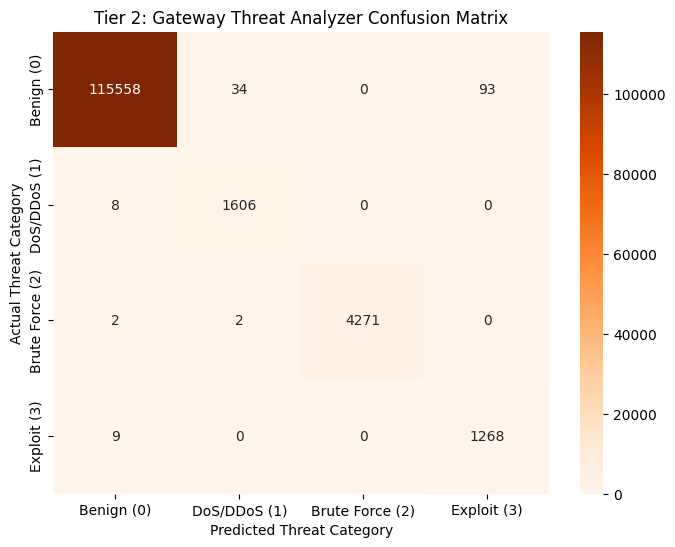

[+] Pipeline saved to models/tier2_gateway_pipeline.pkl


In [9]:
print("\n[*] Evaluating Gateway Accuracy...")
y_pred = tier2_pipeline.predict(X_test)

target_names = ['Benign (0)', 'DoS/DDoS (1)', 'Brute Force (2)', 'Exploit (3)']
print("\n--- Multi-Class Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Tier 2: Gateway Threat Analyzer Confusion Matrix')
plt.ylabel('Actual Threat Category')
plt.xlabel('Predicted Threat Category')
plt.show()

os.makedirs("../models", exist_ok=True)
joblib.dump(tier2_pipeline, '../models/tier2_gateway_pipeline.pkl')
print("[+] Pipeline saved to models/tier2_gateway_pipeline.pkl")

In [10]:
import pandas as pd
import numpy as np

print("[*] Extracting XGBoost Feature Importances (Gain)...")

numeric_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][2]
all_features = numeric_features + categorical_features

importances = tier2_pipeline.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({'Feature': all_features, 'Importance': importances})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print("\n--- Top 15 Most Important Gateway Features ---")
print(feature_importance.head(15))

[*] Extracting XGBoost Feature Importances (Gain)...

--- Top 15 Most Important Gateway Features ---
                      Feature  Importance
21          dst2src_stddev_ps    0.422973
43        src2dst_syn_packets    0.083119
95                    history    0.051700
20            dst2src_mean_ps    0.041389
86             splt_piat_ms_1    0.039689
22             dst2src_max_ps    0.039200
4         bidirectional_bytes    0.038602
23  bidirectional_min_piat_ms    0.034625
48        src2dst_psh_packets    0.028353
57        dst2src_rst_packets    0.027681
99                 sni_domain    0.022489
75                  splt_ps_0    0.018012
35  bidirectional_syn_packets    0.016254
6             src2dst_packets    0.014300
90             splt_piat_ms_5    0.013178
